# 18 · 전체 채널 탐색용 리텐션 모델

**한 줄 답:** 지금 데이터로도 탐색용 모델은 학습한다. 단, 운영 투입용이 아니라 “초반 10분 신호가 후속 행동 24시간 라벨을 얼마나 가르는지” 보는 파이프라인이다.

**타깃:** `later_active` = 첫 관측 후 10분 이후~24시간 안에 의도적 행동이 1회 이상 있는가. 현재 12/95.

**금지:** A/B 효과 해석, 날짜를 주 모델 피처로 사용, 10분 이후 행동/총량을 피처로 사용, W&B 업로드, 운영 계수 교체.

**성공 기준:** majority AUC 0.50, 단일 피처 raw-rank baseline, compact logistic을 비교한다. 단일 초반 신호가 가장 강하면 그 자체를 결과로 기록한다.

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))
from calm_ml import report as R

R.setup()
SRC = ROOT / 'ml/reports/g3_all_channel_later_targets_2026-09-15/all_channel_later_target_candidates.csv'
OUT = ROOT / 'ml/reports/g4_all_channel_exploratory_model_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

def bootstrap_ci(y, p, metric, n_boot=2000, seed=15):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    vals = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        if len(np.unique(y[s])) < 2:
            continue
        vals.append(metric(y[s], p[s]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def clean_json(value):
    if isinstance(value, float) and not np.isfinite(value):
        return None
    if isinstance(value, dict):
        return {k: clean_json(v) for k, v in value.items()}
    if isinstance(value, list):
        return [clean_json(v) for v in value]
    return value

def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=2)),
        ]), cat_cols),
    ])

def cv_predict(df, y, num_cols, cat_cols, C=0.5):
    pipe = Pipeline([
        ('prep', make_preprocessor(num_cols, cat_cols)),
        ('clf', LogisticRegression(
            penalty='l2',
            C=C,
            class_weight='balanced',
            solver='liblinear',
            max_iter=1000,
            random_state=15,
        )),
    ])
    cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=25, random_state=15)
    X = df[num_cols + cat_cols]
    pred_sum = np.zeros(len(y), dtype=float)
    pred_count = np.zeros(len(y), dtype=float)
    for tr, te in cv.split(X, y):
        fold_pipe = clone(pipe)
        fold_pipe.fit(X.iloc[tr], y[tr])
        pred_sum[te] += fold_pipe.predict_proba(X.iloc[te])[:, 1]
        pred_count[te] += 1
    p = pred_sum / pred_count
    pipe.fit(df[num_cols + cat_cols], y)
    return p, pipe


## 1. 데이터와 피처

입력은 17번 노트북이 만든 익명 기기 후보표다. 피처는 첫 10분 안에서만 만든다. `later_*` 컬럼은 라벨과 검산용으로만 쓰고 학습 입력에서 제외한다.

In [2]:
raw = pd.read_csv(SRC)
assert raw.device_label.is_unique
assert len(raw) == 95

d = raw.copy()
d['y'] = d.later_active.astype(bool).astype(int)
d['is_toss_observed'] = (d.channel_segment == '토스 관측').astype(int)
d['is_mobile'] = (d.device == 'mobile').astype(int)
d['is_south_korea'] = (d.country_group == 'South Korea').astype(int)
d['log_early_tracked_events'] = np.log1p(d.early_tracked_events)
d['log_early_actions'] = np.log1p(d.early_actions)
d['has_early_action'] = (d.early_actions > 0).astype(int)
d['has_early_nature'] = (d.early_nature_events > 0).astype(int)
d['has_early_fishing_sea'] = (d.early_fishing_sea_events > 0).astype(int)
d['has_early_quest_social'] = (d.early_quest_social_events > 0).astype(int)
d['has_early_craft_home'] = (d.early_craft_home_events > 0).astype(int)
d['has_early_advanced'] = (d.early_advanced_events > 0).astype(int)
d['has_early_connect_fail'] = (d.early_connect_fail > 0).astype(int)
d['has_early_connect_ok'] = (d.early_connect_ok > 0).astype(int)
d['has_early_toss_login'] = (d.early_toss_login > 0).astype(int)
d['has_early_login_screen'] = (d.early_login_screen > 0).astype(int)
d['first_day_str'] = pd.to_datetime(d.first_day).dt.strftime('%Y-%m-%d')

blocked = [c for c in d.columns if c.startswith('later_')]
print('n=', len(d), 'positive=', int(d.y.sum()), 'rate=', f'{d.y.mean():.1%}')
print('blocked later columns:', blocked)
display(d[['device_label','channel_segment','early_actions','early_area_count','early_connection_segment','y']].head(10))


n= 95 positive= 12 rate= 12.6%
blocked later columns: ['later_actions', 'later_action_kinds', 'later_area_count', 'later_nature_events', 'later_fishing_sea_events', 'later_quest_social_events', 'later_craft_home_events', 'later_advanced_events', 'later_new_nature_events', 'later_new_fishing_sea_events', 'later_new_quest_social_events', 'later_new_craft_home_events', 'later_new_advanced_events', 'later_active', 'later_new_area', 'later_quest_social', 'later_fishing_sea', 'later_nature']


,device_label,channel_segment,early_actions,early_area_count,early_connection_segment,y
0,D001,토스 관측,111,3,토스 연결 성공만 기록,1
1,D002,메인·웹만,7,3,토스 연결 이벤트 없음,1
2,D003,메인·웹만,0,0,토스 연결 이벤트 없음,0
3,D004,메인·웹만,0,0,토스 연결 이벤트 없음,0
4,D005,메인·웹만,0,0,토스 연결 이벤트 없음,0
5,D006,토스 관측,0,0,토스 연결 실패 기록,0
6,D007,메인·웹만,0,0,토스 연결 이벤트 없음,0
7,D008,토스 관측,100,5,토스 연결 이벤트 없음,1
8,D009,토스 관측,88,4,토스 연결 실패 기록,1
9,D010,메인·웹만,0,0,토스 연결 이벤트 없음,0


## 2. 모델 후보

작게 간다. AUC를 올리려고 피처를 마구 고르지 않고, 해석 가능한 묶음만 비교한다.

In [3]:
feature_sets = {
    'compact_behavior': ([
        'is_toss_observed', 'log_early_tracked_events', 'log_early_actions',
        'early_action_kinds', 'early_area_count',
        'has_early_nature', 'has_early_fishing_sea', 'has_early_quest_social',
        'has_early_craft_home', 'has_early_advanced',
        'has_early_connect_fail', 'has_early_connect_ok',
        'has_early_toss_login', 'has_early_login_screen',
    ], []),
    'compact_plus_profile': ([
        'is_toss_observed', 'is_mobile', 'is_south_korea',
        'log_early_tracked_events', 'log_early_actions',
        'early_action_kinds', 'early_area_count',
        'has_early_nature', 'has_early_fishing_sea', 'has_early_quest_social',
        'has_early_craft_home', 'has_early_advanced',
        'has_early_connect_fail', 'has_early_connect_ok',
        'has_early_toss_login', 'has_early_login_screen',
    ], ['acquisition_source']),
    'date_sensitivity_not_for_serving': ([
        'is_toss_observed', 'log_early_tracked_events', 'log_early_actions',
        'early_action_kinds', 'early_area_count',
        'has_early_nature', 'has_early_fishing_sea', 'has_early_quest_social',
        'has_early_craft_home', 'has_early_advanced',
        'has_early_connect_fail', 'has_early_connect_ok',
        'has_early_toss_login', 'has_early_login_screen',
    ], ['first_day_str']),
}

y = d.y.to_numpy()
rows = []
preds = {}
models = {}

majority_p = np.repeat(y.mean(), len(y))
rows.append({
    'model': 'majority_prevalence',
    'kind': 'baseline',
    'features': 0,
    'auc': 0.5,
    'auc_ci_low': 0.5,
    'auc_ci_high': 0.5,
    'pr_auc': float(average_precision_score(y, majority_p)),
    'balanced_acc_at_0_5': 0.5,
})

raw_baselines = {
    'channel_raw_rank': d.is_toss_observed.to_numpy(),
    'early_actions_raw_rank': d.early_actions.to_numpy(),
    'early_area_raw_rank': d.early_area_count.to_numpy(),
    'early_tracked_raw_rank': d.early_tracked_events.to_numpy(),
}
for name, score in raw_baselines.items():
    auc = float(roc_auc_score(y, score))
    ci_low, ci_high = bootstrap_ci(y, score, roc_auc_score)
    rows.append({
        'model': name,
        'kind': 'raw_rank_baseline',
        'features': 1,
        'auc': auc,
        'auc_ci_low': ci_low,
        'auc_ci_high': ci_high,
        'pr_auc': float(average_precision_score(y, score)),
        'balanced_acc_at_0_5': None,
        'balanced_acc_at_median_score': None,
    })

for name, (num_cols, cat_cols) in feature_sets.items():
    p, pipe = cv_predict(d, y, num_cols, cat_cols)
    auc = float(roc_auc_score(y, p))
    ci_low, ci_high = bootstrap_ci(y, p, roc_auc_score)
    pr = float(average_precision_score(y, p))
    pred_label = (p >= np.median(p)).astype(int)
    rows.append({
        'model': name,
        'kind': 'cv_logistic',
        'features': len(num_cols) + len(cat_cols),
        'auc': auc,
        'auc_ci_low': ci_low,
        'auc_ci_high': ci_high,
        'pr_auc': pr,
        'balanced_acc_at_median_score': float(balanced_accuracy_score(y, pred_label)),
    })
    preds[name] = p
    models[name] = pipe

metrics = pd.DataFrame(rows).sort_values('auc', ascending=False)
metrics.to_csv(OUT / 'model_metrics.csv', index=False)
display(metrics)


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

...

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

,model,kind,features,auc,auc_ci_low,auc_ci_high,pr_auc,balanced_acc_at_0_5,balanced_acc_at_median_score
4,early_tracked_raw_rank,raw_rank_baseline,1,0.883032,0.779072,0.965314,0.665163,NaN,NaN
6,compact_plus_profile,cv_logistic,17,0.846386,0.707223,0.968239,0.669149,NaN,0.687751
7,date_sensitivity_not_for_serving,cv_logistic,15,0.801205,0.623469,0.955049,0.597145,NaN,0.640060
5,compact_behavior,cv_logistic,14,0.788153,0.603359,0.946685,0.563627,NaN,0.640060
2,early_actions_raw_rank,raw_rank_baseline,1,0.760542,0.596829,0.921670,0.554332,NaN,NaN
3,early_area_raw_rank,raw_rank_baseline,1,0.757028,0.595773,0.910728,0.436326,NaN,NaN
1,channel_raw_rank,raw_rank_baseline,1,0.604418,0.452078,0.748160,0.158047,NaN,NaN
0,majority_prevalence,baseline,0,0.500000,0.500000,0.500000,0.126316,0.5,NaN


## 3. AUC 비교

날짜 민감도 모델은 운영 후보가 아니다. 날짜를 넣어서 오르면 코호트 꼬리를 외웠을 가능성이 커진다.

g4_all_channel_exploratory_auc.png  1224x631px


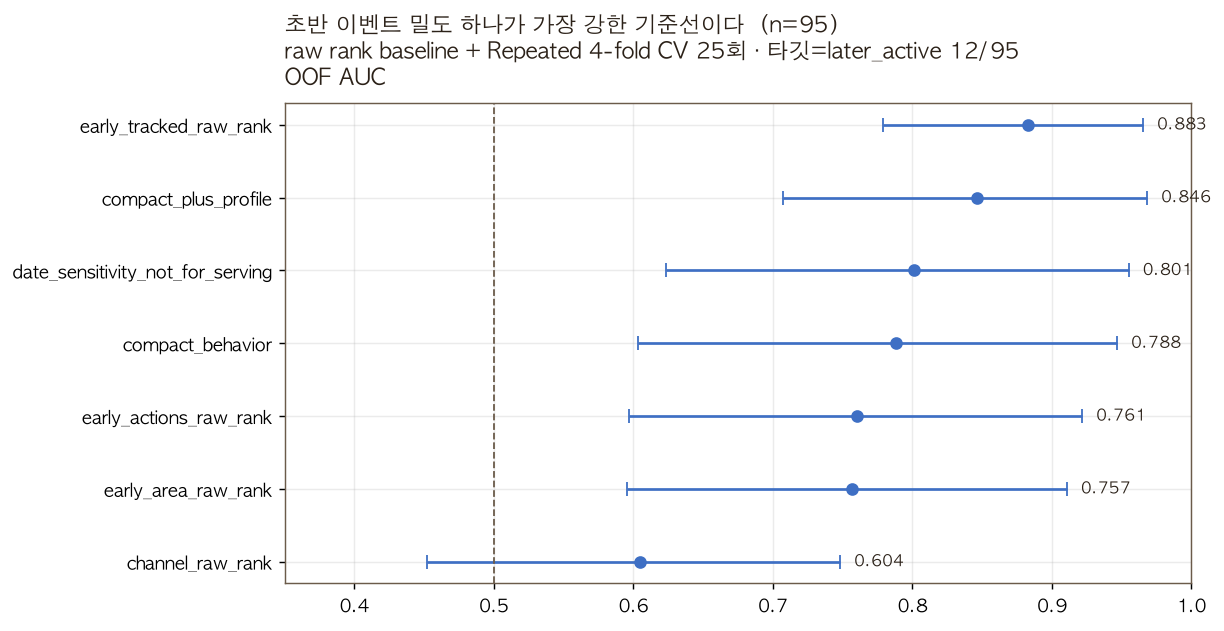

In [4]:
plot = metrics[metrics.model != 'majority_prevalence'].copy().sort_values('auc')
fig, ax = R.new(
    '초반 이벤트 밀도 하나가 가장 강한 기준선이다',
    len(d),
    sub='raw rank baseline + Repeated 4-fold CV 25회 · 타깃=later_active 12/95',
    ylab='OOF AUC',
    figsize=(9, 4.8),
)
ypos = range(len(plot))
ax.errorbar(
    plot.auc,
    list(ypos),
    xerr=[plot.auc - plot.auc_ci_low, plot.auc_ci_high - plot.auc],
    fmt='o',
    color=R.PALETTE[1],
    capsize=4,
)
ax.axvline(.5, color=R.MUTED, linestyle='--', linewidth=1)
ax.set_yticks(list(ypos), plot.model)
ax.set_xlim(.35, min(1, max(plot.auc_ci_high) * 1.04))
for i, row in enumerate(plot.itertuples()):
    ax.text(row.auc_ci_high + 0.01, i, f'{row.auc:.3f}', va='center', fontsize=9)
chart_auc = R.save(fig, ax, 'g4_all_channel_exploratory_auc', zero_base=False)
print(R.check(chart_auc))
display(R.show(chart_auc))


## 4. 가장 나은 compact 모델의 계수

계수는 방향을 보는 참고값이다. 표본이 작아 계수 하나하나를 제품 규칙으로 옮기지 않는다.

best serving-eligible model: compact_plus_profile


,feature,coef,abs_coef
3,log_early_tracked_events,1.418034,1.418034
1,is_mobile,-1.238684,1.238684
16,acquisition_source_(direct),-0.548012,0.548012
9,has_early_quest_social,-0.525267,0.525267
13,has_early_connect_ok,0.503093,0.503093
2,is_south_korea,0.490119,0.490119
5,early_action_kinds,0.449062,0.449062
8,has_early_fishing_sea,0.359862,0.359862
15,has_early_login_screen,0.354409,0.354409
11,has_early_advanced,0.353442,0.353442


g4_all_channel_exploratory_coefficients.png  1152x671px


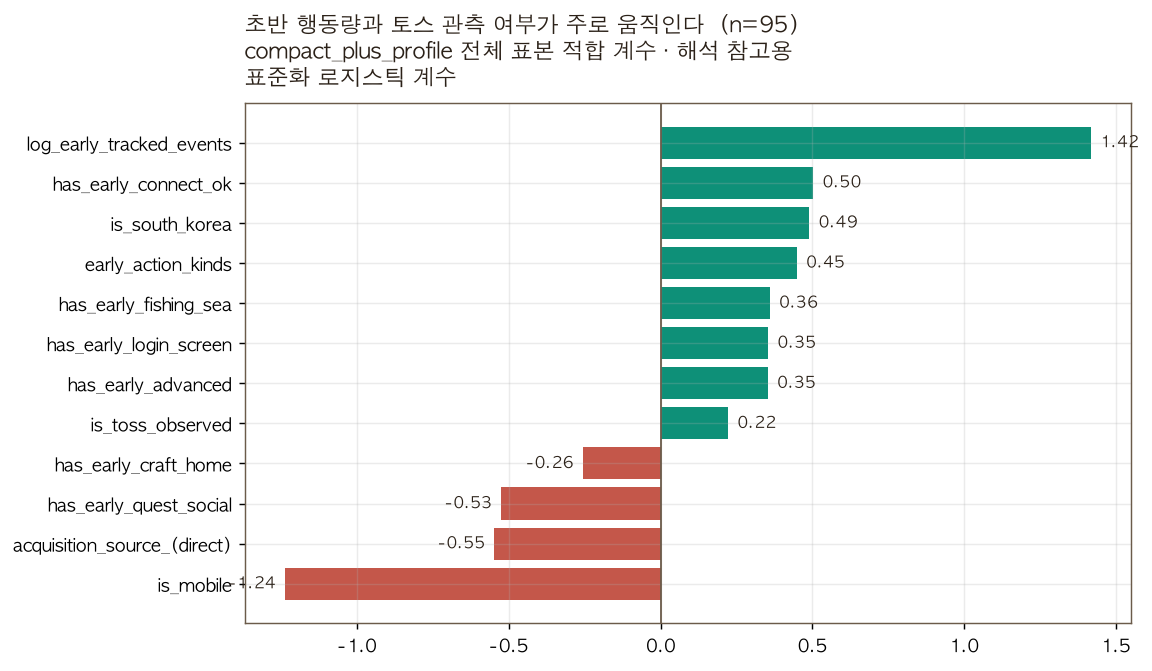

In [5]:
best_name = metrics[
    (metrics.kind == 'cv_logistic') & (metrics.model != 'date_sensitivity_not_for_serving')
].sort_values('auc', ascending=False).iloc[0].model
best_pipe = models[best_name]
num_cols, cat_cols = feature_sets[best_name]
prep = best_pipe.named_steps['prep']
clf = best_pipe.named_steps['clf']

names = []
if num_cols:
    names.extend(num_cols)
if cat_cols:
    enc = prep.named_transformers_['cat'].named_steps['onehot']
    names.extend(enc.get_feature_names_out(cat_cols).tolist())

coef = pd.DataFrame({'feature': names, 'coef': clf.coef_[0]})
coef['abs_coef'] = coef.coef.abs()
coef = coef.sort_values('abs_coef', ascending=False)
coef.to_csv(OUT / 'best_model_coefficients.csv', index=False)
print('best serving-eligible model:', best_name)
display(coef.head(16))

plot = coef.head(12).sort_values('coef')
fig, ax = R.new(
    '초반 행동량과 토스 관측 여부가 주로 움직인다',
    len(d),
    sub=f'{best_name} 전체 표본 적합 계수 · 해석 참고용',
    ylab='표준화 로지스틱 계수',
    figsize=(8.8, 5.2),
)
colors = [R.PALETTE[2] if v > 0 else R.PALETTE[0] for v in plot.coef]
bars = ax.barh(plot.feature, plot.coef, color=colors)
ax.axvline(0, color=R.MUTED, linewidth=1)
for bar, value in zip(bars, plot.coef):
    ax.text(value + (0.03 if value >= 0 else -0.03), bar.get_y()+bar.get_height()/2, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=9)
chart_coef = R.save(fig, ax, 'g4_all_channel_exploratory_coefficients', zero_base=False)
print(R.check(chart_coef))
display(R.show(chart_coef))


## 5. 점수 분포

운영 임계값을 정하지 않는다. 여기서는 양성/음성 점수가 얼마나 갈라지는지만 본다.

g4_all_channel_exploratory_scores.png  929x620px


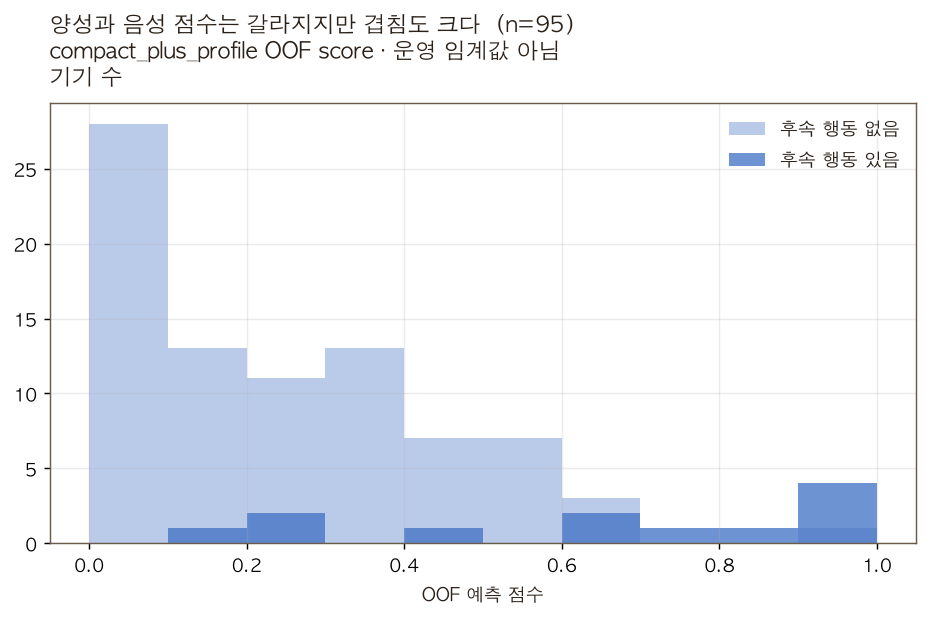

In [6]:
score_df = d[['device_label', 'channel_segment', 'early_action_segment', 'y']].copy()
score_df['score'] = preds[best_name]
score_df.to_csv(OUT / 'best_model_oof_scores.csv', index=False)

fig, ax = R.new(
    '양성과 음성 점수는 갈라지지만 겹침도 크다',
    len(d),
    sub=f'{best_name} OOF score · 운영 임계값 아님',
    ylab='기기 수',
    figsize=(8.6, 4.4),
)
bins = np.linspace(0, 1, 11)
ax.hist(score_df.query('y == 0').score, bins=bins, alpha=.65, color=R.tint(R.PALETTE[1], .45), label='후속 행동 없음')
ax.hist(score_df.query('y == 1').score, bins=bins, alpha=.75, color=R.PALETTE[1], label='후속 행동 있음')
ax.set_xlabel('OOF 예측 점수')
ax.legend(frameon=False)
chart_score = R.save(fig, ax, 'g4_all_channel_exploratory_scores')
print(R.check(chart_score))
display(R.show(chart_score))


## 6. 보조 라벨은 아직 학습하지 않는다

`새 영역`, `퀘스트·교류`, `낚시·바다`는 제품 로직에 더 가깝지만 양성이 7~9대다. 이번 노트북에서는 학습 타깃으로 쓰지 않고 양성 수만 남긴다.

In [7]:
aux = pd.DataFrame({
    'target': ['later_new_area', 'later_quest_social', 'later_fishing_sea', 'later_nature'],
    'positives': [
        int(d.later_new_area.sum()),
        int(d.later_quest_social.sum()),
        int(d.later_fishing_sea.sum()),
        int(d.later_nature.sum()),
    ],
    'n': len(d),
})
aux['positive_rate'] = aux.positives / aux.n
aux.to_csv(OUT / 'auxiliary_target_counts.csv', index=False)
display(aux)


,target,positives,n,positive_rate
0,later_new_area,9,95,0.094737
1,later_quest_social,9,95,0.094737
2,later_fishing_sea,8,95,0.084211
3,later_nature,7,95,0.073684


## 7. 판정

탐색용으로는 학습할 수 있다. 운영 투입용은 아니다.

- `later_active`는 12/95라 baseline 비교가 가능하다.
- compact 모델과 단일 raw-rank 기준선을 같이 본다. 단일 피처가 더 높으면 단순 신호를 우선한다.
- 날짜를 넣은 모델이 더 좋아져도 배포 후보로 보지 않는다.
- 계수 파일을 운영 경로에 쓰지 않는다.

In [8]:
artifact = {
    'analysis': 'g4-all-channel-exploratory-retention-model',
    'date': '2026-09-15',
    'source': str(SRC),
    'target': 'later_active',
    'n': int(len(d)),
    'positives': int(d.y.sum()),
    'best_serving_eligible_model': str(best_name),
    'metrics': metrics.to_dict(orient='records'),
    'constraints': [
        'exploratory only',
        'no A/B effect analysis',
        'no post-10-minute features',
        'no production coefficient export',
        'no W&B upload',
    ],
}
artifact = clean_json(artifact)
(OUT / 'model_audit.json').write_text(json.dumps(artifact, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
display(Markdown('```json\n' + json.dumps(artifact, ensure_ascii=False, indent=2, allow_nan=False) + '\n```'))


```json
{
  "analysis": "g4-all-channel-exploratory-retention-model",
  "date": "2026-09-15",
  "source": "/Users/uicheol_hwang/calm_forest/ml/reports/g3_all_channel_later_targets_2026-09-15/all_channel_later_target_candidates.csv",
  "target": "later_active",
  "n": 95,
  "positives": 12,
  "best_serving_eligible_model": "compact_plus_profile",
  "metrics": [
    {
      "model": "early_tracked_raw_rank",
      "kind": "raw_rank_baseline",
      "features": 1,
      "auc": 0.8830321285140562,
      "auc_ci_low": 0.7790720493411831,
      "auc_ci_high": 0.9653144016227181,
      "pr_auc": 0.6651626228308476,
      "balanced_acc_at_0_5": null,
      "balanced_acc_at_median_score": null
    },
    {
      "model": "compact_plus_profile",
      "kind": "cv_logistic",
      "features": 17,
      "auc": 0.8463855421686748,
      "auc_ci_low": 0.707222678343368,
      "auc_ci_high": 0.9682391818796484,
      "pr_auc": 0.6691494323481901,
      "balanced_acc_at_0_5": null,
      "balanced_acc_at_median_score": 0.6877510040160643
    },
    {
      "model": "date_sensitivity_not_for_serving",
      "kind": "cv_logistic",
      "features": 15,
      "auc": 0.8012048192771084,
      "auc_ci_low": 0.623469126506024,
      "auc_ci_high": 0.9550485422436641,
      "pr_auc": 0.597144507992343,
      "balanced_acc_at_0_5": null,
      "balanced_acc_at_median_score": 0.6400602409638554
    },
    {
      "model": "compact_behavior",
      "kind": "cv_logistic",
      "features": 14,
      "auc": 0.7881526104417671,
      "auc_ci_low": 0.603359173126615,
      "auc_ci_high": 0.9466847133643983,
      "pr_auc": 0.5636265872285608,
      "balanced_acc_at_0_5": null,
      "balanced_acc_at_median_score": 0.6400602409638554
    },
    {
      "model": "early_actions_raw_rank",
      "kind": "raw_rank_baseline",
      "features": 1,
      "auc": 0.7605421686746988,
      "auc_ci_low": 0.596829474071104,
      "auc_ci_high": 0.9216702174551866,
      "pr_auc": 0.5543322337181986,
      "balanced_acc_at_0_5": null,
      "balanced_acc_at_median_score": null
    },
    {
      "model": "early_area_raw_rank",
      "kind": "raw_rank_baseline",
      "features": 1,
      "auc": 0.7570281124497992,
      "auc_ci_low": 0.5957733896850276,
      "auc_ci_high": 0.9107278138528138,
      "pr_auc": 0.43632621439638986,
      "balanced_acc_at_0_5": null,
      "balanced_acc_at_median_score": null
    },
    {
      "model": "channel_raw_rank",
      "kind": "raw_rank_baseline",
      "features": 1,
      "auc": 0.6044176706827309,
      "auc_ci_low": 0.4520779454022989,
      "auc_ci_high": 0.7481597087796273,
      "pr_auc": 0.15804729214340196,
      "balanced_acc_at_0_5": null,
      "balanced_acc_at_median_score": null
    },
    {
      "model": "majority_prevalence",
      "kind": "baseline",
      "features": 0,
      "auc": 0.5,
      "auc_ci_low": 0.5,
      "auc_ci_high": 0.5,
      "pr_auc": 0.12631578947368421,
      "balanced_acc_at_0_5": 0.5,
      "balanced_acc_at_median_score": null
    }
  ],
  "constraints": [
    "exploratory only",
    "no A/B effect analysis",
    "no post-10-minute features",
    "no production coefficient export",
    "no W&B upload"
  ]
}
```